In [ ]:
!pip install librosa

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files

uploaded = files.upload()

KeyboardInterrupt: 

In [ ]:
import os

print(os.listdir())

In [ ]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('EmotionDataset')

print("Extraction Complete!")

In [ ]:
import os

print(os.listdir('EmotionDataset'))

In [ ]:
import os

dataset_path = "EmotionDataset"

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            print("Found:", os.path.join(root, file))
            break
    break

In [ ]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def extract_features(file_path):

    signal, sample_rate = librosa.load(
        file_path,
        duration=3,
        offset=0.5
    )

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sample_rate,
        n_mfcc=40
    )

    mfcc_scaled = np.mean(mfcc.T, axis=0)

    return mfcc_scaled

In [ ]:
import os

dataset_path = "EmotionDataset"

for root, dirs, files in os.walk(dataset_path):
    print("Current Folder:", root)
    print("Files:", files[:5])
    break

Current Folder: EmotionDataset
Files: []


In [ ]:
sample_file = "EmotionDataset/Actor_01/03-01-01-01-01-01-01.wav"

features = extract_features(sample_file)

print(features.shape)
print(features)

(40,)
[-6.7019543e+02  6.5063850e+01  8.8895458e-01  1.4715980e+01
  9.1821632e+00  6.6057539e-01 -3.8468375e+00 -3.5839458e+00
 -1.2959006e+01 -3.3001344e+00  9.1078007e-01 -3.5970366e+00
  2.3762748e+00 -4.3889418e+00  5.4507905e-01  8.9185232e-01
 -4.8025889e+00 -2.1054149e+00 -1.6059679e+00 -1.0523908e+00
 -7.0672803e+00 -6.2306064e-01 -2.7280300e+00 -5.3073611e+00
 -1.9691176e+00 -9.4615269e-01 -5.7211113e+00  3.3299074e-01
 -2.5438442e+00  1.8220778e-01 -2.3510973e+00 -2.5047286e+00
 -3.1515048e+00 -2.1908996e+00 -3.8017614e+00 -1.8130866e+00
 -1.2612233e+00 -2.1449544e+00 -4.1521721e+00 -1.7796165e+00]


In [ ]:
features = []
labels = []

dataset_path = "EmotionDataset"

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.endswith(".wav"):

            file_path = os.path.join(root, file)

            feature = extract_features(file_path)

            emotion = file.split("-")[2]

            features.append(feature)
            labels.append(emotion)

print("Total Samples:", len(features))

Total Samples: 2880


In [ ]:
print(labels[:10])

['04', '03', '03', '05', '07', '04', '04', '01', '04', '02']


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import numpy as np

X = np.array(features)

encoder = LabelEncoder()

y = encoder.fit_transform(labels)

y = to_categorical(y)

print("X Shape:", X.shape)
print("Y Shape:", y.shape)

X Shape: (2880, 40)
Y Shape: (2880, 8)


In [ ]:
print(encoder.classes_)

['01' '02' '03' '04' '05' '06' '07' '08']


In [ ]:
from sklearn.model_selection import train_test_split

X = X.reshape(X.shape[0], X.shape[1], 1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (2304, 40, 1)
Testing Data: (576, 40, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential()

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(40,1)
    )
)

model.add(MaxPooling1D(pool_size=2))

model.add(
    LSTM(
        64,
        return_sequences=False
    )
)

model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

model.add(Dense(8, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 38, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,624 (139.16 KB)

 Trainable params: 35,624 (139.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.1780 - loss: 2.0240 - val_accuracy: 0.2448 - val_loss: 1.9935
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2504 - loss: 1.9310 - val_accuracy: 0.3281 - val_loss: 1.8256
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2973 - loss: 1.8251 - val_accuracy: 0.3628 - val_loss: 1.7526
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3420 - loss: 1.7430 - val_accuracy: 0.3663 - val_loss: 1.6704
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3655 - loss: 1.6976 - val_accuracy: 0.3715 - val_loss: 1.6299
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3763 - loss: 1.6441 - val_accuracy: 0.3872 - val_loss: 1.5847
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4076 - loss: 1.6080 - val_accuracy: 0.4028 - val_loss: 1.5341
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4123 - loss: 1.5595 - val_accuracy: 0.4375 - val_loss

In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5642 - loss: 1.1245
Test Accuracy: 0.5642361044883728


In [ ]:
model.save("emotion_recognition_model.h5")

In [ ]:
print("Test Accuracy:", accuracy)

Test Accuracy: 0.5642361044883728


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy * 100)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5642 - loss: 1.1245
Test Accuracy: 56.42361044883728


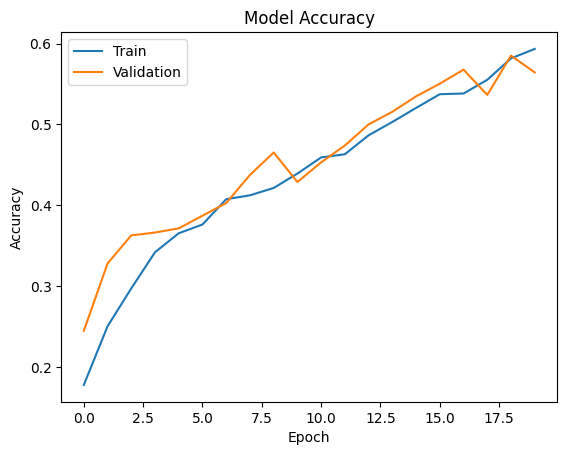

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])

plt.show()

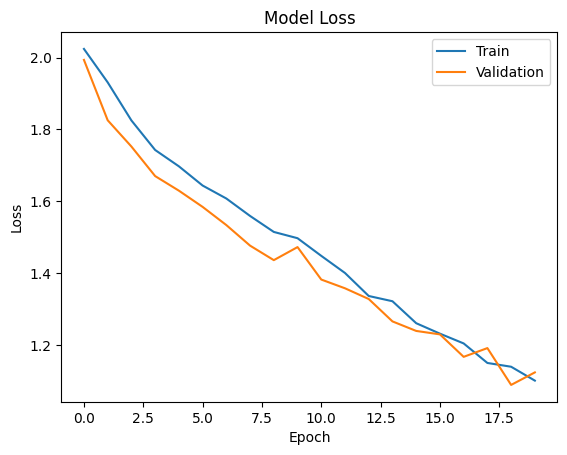

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])

plt.show()

In [ ]:
sample = X_test[0].reshape(1,40,1)

prediction = model.predict(sample)

predicted_class = np.argmax(prediction)

print("Predicted Emotion Code:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
Predicted Emotion Code: 5


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


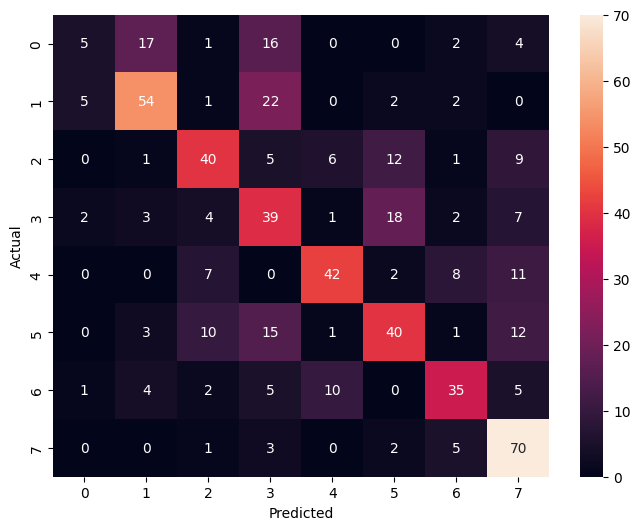

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from google.colab import files

files.download("emotion_recognition_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("emotion_recognition_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

print(os.listdir())

['.config', 'drive', 'EmotionDataset', 'archive (1).zip', '03-01-01-01-01-01-01.wav', 'emotion_recognition_model.h5', 'archive.zip', 'sample_data']


In [ ]:
model.save("emotion_recognition_model.h5")

In [ ]:
print(os.listdir())

['.config', 'drive', 'EmotionDataset', 'archive (1).zip', '03-01-01-01-01-01-01.wav', 'emotion_recognition_model.h5', 'archive.zip', 'sample_data']


In [ ]:
from google.colab import files

files.download("emotion_recognition_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>